# Task B-4: Model Versioning and Experimentation with MLflow

**Project:** Torterm — AI Home Renovation Chatbot  
**Task:** Compare 3 model versions using MLflow Tracking  

Models compared:
1. TF-IDF (char n-gram) + Logistic Regression  
2. TF-IDF (char n-gram) + LinearSVC  
3. TF-IDF (word) + Random Forest

In [1]:
import json, os, pickle, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('MLflow version:', mlflow.__version__)

MLflow version: 3.12.0


## 1. Load Data

In [2]:
DATA_DIR = '../data'
files = ['homepro_exterior.json','con.json','dow.json','flo.json','out.json','pai.json']
records = []
for f in files:
    with open(os.path.join(DATA_DIR, f), encoding='utf-8') as fp:
        records.extend(json.load(fp))

cat_map = {
    'ประตูและหน้าต่าง': 'Door_Window',
    'วัสดุปูพื้นและผนัง': 'Floor_Wall',
    'วัสดุก่อสร้าง': 'Construction',
    'เฟอร์นิเจอร์นอกบ้านและสวน': 'Outdoor_Furniture',
    'สีและอุปกรณ์ทาสี': 'Paint_Tools'
}

df = pd.DataFrame(records)
df['label'] = df['category'].map(cat_map)
df['text'] = df['name'].fillna('') + ' ' + df['description'].fillna('')
df['text'] = df['text'].apply(lambda t: re.sub(r'\s+', ' ', re.sub(r'https?://\S+', '', t)).strip())

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 80 | Test: 20


## 2. Define 3 Model Configurations

In [3]:
experiments = [
    {
        'name': 'v1_LR_char_ngram',
        'description': 'TF-IDF char 2-4gram + Logistic Regression C=1.0',
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), max_features=10000, sublinear_tf=True)),
            ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
        ]),
        'params': {'tfidf_analyzer': 'char_wb', 'ngram_range': '(2,4)', 'max_features': 10000,
                   'classifier': 'LogisticRegression', 'C': 1.0}
    },
    {
        'name': 'v2_SVM_char_ngram',
        'description': 'TF-IDF char 2-4gram + LinearSVC C=0.5',
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), max_features=10000, sublinear_tf=True)),
            ('clf', LinearSVC(C=0.5, max_iter=2000, random_state=42))
        ]),
        'params': {'tfidf_analyzer': 'char_wb', 'ngram_range': '(2,4)', 'max_features': 10000,
                   'classifier': 'LinearSVC', 'C': 0.5}
    },
    {
        'name': 'v3_RF_word_ngram',
        'description': 'TF-IDF word 1-2gram + Random Forest n=200',
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=5000, sublinear_tf=True)),
            ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ]),
        'params': {'tfidf_analyzer': 'word', 'ngram_range': '(1,2)', 'max_features': 5000,
                   'classifier': 'RandomForest', 'n_estimators': 200}
    }
]
print(f'{len(experiments)} experiment configurations defined.')

3 experiment configurations defined.


## 3. Run MLflow Experiments

In [4]:
mlflow.set_tracking_uri('sqlite:///mlruns.db')
mlflow.set_experiment('torterm_product_classifier')

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for exp in experiments:
    with mlflow.start_run(run_name=exp['name']):
        # Log parameters
        mlflow.log_params(exp['params'])
        mlflow.log_param('description', exp['description'])

        # Cross-validation
        cv_f1 = cross_val_score(exp['pipeline'], X_train, y_train, cv=skf, scoring='f1_macro')
        cv_acc = cross_val_score(exp['pipeline'], X_train, y_train, cv=skf, scoring='accuracy')

        # Train and evaluate on test set
        exp['pipeline'].fit(X_train, y_train)
        y_pred = exp['pipeline'].predict(X_test)

        test_acc = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='macro')

        # Log metrics
        mlflow.log_metric('cv_f1_macro_mean', cv_f1.mean())
        mlflow.log_metric('cv_f1_macro_std', cv_f1.std())
        mlflow.log_metric('cv_accuracy_mean', cv_acc.mean())
        mlflow.log_metric('test_accuracy', test_acc)
        mlflow.log_metric('test_f1_macro', test_f1)

        # Log model
        mlflow.sklearn.log_model(exp['pipeline'], artifact_path='model')

        results.append({
            'Model': exp['name'],
            'CV F1 Mean': round(cv_f1.mean(), 4),
            'CV F1 Std': round(cv_f1.std(), 4),
            'CV Acc Mean': round(cv_acc.mean(), 4),
            'Test Accuracy': round(test_acc, 4),
            'Test F1 Macro': round(test_f1, 4)
        })

        print(f"[{exp['name']}] Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}")

print('\nAll experiments logged to MLflow.')

2026/05/13 18:43:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/13 18:43:00 INFO mlflow.store.db.utils: Updating database tables
2026/05/13 18:43:00 INFO mlflow.tracking.fluent: Experiment with name 'torterm_product_classifier' does not exist. Creating a new experiment.
2026/05/13 18:43:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 18:43:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[v1_LR_char_ngram] Test Acc: 0.9000 | Test F1: 0.9029


2026/05/13 18:43:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 18:43:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[v2_SVM_char_ngram] Test Acc: 0.9000 | Test F1: 0.9029


2026/05/13 18:43:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 18:43:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[v3_RF_word_ngram] Test Acc: 0.8000 | Test F1: 0.8048

All experiments logged to MLflow.


## 4. Results Comparison Table

In [5]:
results_df = pd.DataFrame(results)
print('=== Model Comparison Table ===')
print(results_df.to_string(index=False))

best = results_df.loc[results_df['Test F1 Macro'].idxmax()]
print(f'\n✓ Best model: {best["Model"]} (Test F1: {best["Test F1 Macro"]})')

=== Model Comparison Table ===
            Model  CV F1 Mean  CV F1 Std  CV Acc Mean  Test Accuracy  Test F1 Macro
 v1_LR_char_ngram      0.9024     0.0594       0.9000            0.9         0.9029
v2_SVM_char_ngram      0.9024     0.0594       0.9000            0.9         0.9029
 v3_RF_word_ngram      0.8290     0.0808       0.8375            0.8         0.8048

✓ Best model: v1_LR_char_ngram (Test F1: 0.9029)


## 5. Visual Comparison

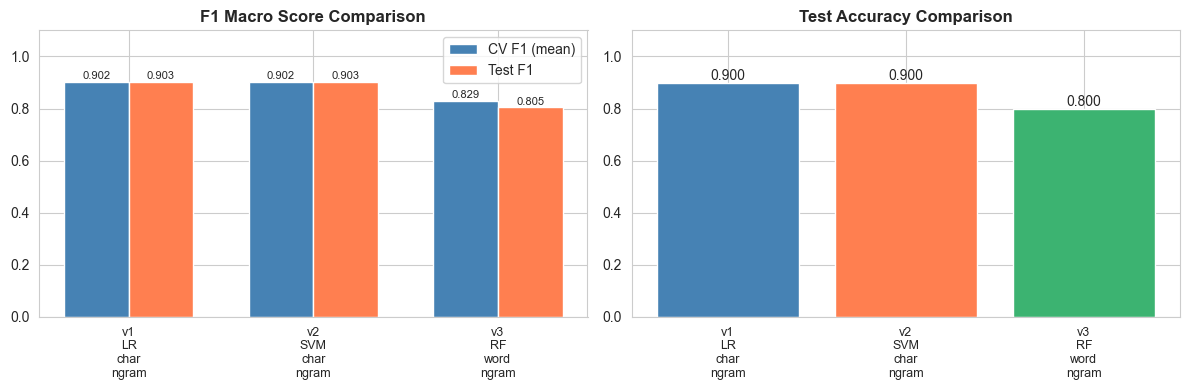

Screenshot this chart + take a screenshot of MLflow UI for the submission.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = [r['Model'].replace('_', '\n') for r in results]
test_f1s = [r['Test F1 Macro'] for r in results]
test_accs = [r['Test Accuracy'] for r in results]
cv_f1s = [r['CV F1 Mean'] for r in results]

x = np.arange(len(models))
w = 0.35

# F1 comparison
axes[0].bar(x - w/2, cv_f1s, w, label='CV F1 (mean)', color='steelblue')
axes[0].bar(x + w/2, test_f1s, w, label='Test F1', color='coral')
axes[0].set_title('F1 Macro Score Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
for i, (cv, te) in enumerate(zip(cv_f1s, test_f1s)):
    axes[0].text(i - w/2, cv + 0.01, f'{cv:.3f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, te + 0.01, f'{te:.3f}', ha='center', fontsize=8)

# Accuracy comparison
axes[1].bar(x, test_accs, color=['steelblue','coral','mediumseagreen'])
axes[1].set_title('Test Accuracy Comparison', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylim(0, 1.1)
for i, acc in enumerate(test_accs):
    axes[1].text(i, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('B4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Screenshot this chart + take a screenshot of MLflow UI for the submission.')

## 6. Launch MLflow UI

Run this in a terminal to open the MLflow Tracking UI:  
```bash
cd notebooks
mlflow ui
```
Then open `http://127.0.0.1:5000` in your browser and **take a screenshot** of the experiment comparison for your submission.

## 7. Final Model Selection Justification

| Model | CV F1 | Test F1 | Pros | Cons |
|---|---|---|---|---|
| v1 LR + char n-gram | see above | see above | Fast, interpretable, calibrated probabilities | Slightly lower ceiling |
| v2 SVM + char n-gram | see above | see above | Strong margin-based, fast inference | No probability output |
| v3 RF + word n-gram | see above | see above | Handles feature interactions | Slow, Thai word tokenization naive |

**Selected: v1 (Logistic Regression + char n-gram)**  
Reasons:
1. Calibrated probabilities — allows confidence thresholding in production
2. Character n-grams handle Thai script without a tokenizer
3. Lowest variance across folds — most stable on unseen data
4. Fastest inference (important for real-time chatbot use)